In [1]:
import itertools
import string
import warnings
from typing import Any

import numpy as np
import numpy.typing as npt
import pandas as pd
from gensim.models import Word2Vec
from matplotlib import pyplot as plt
from sklearn import metrics
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC, LinearSVC

from helper import *
from project1 import *

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
import seaborn as sns

import ssl
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download('punkt')
nltk.download('stopwords')

/var/folders/hg/y1zjds8x0d7d9qvr2zyw3r940000gn/T/ipykernel_19955/2107570269.py:8: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd
[nltk_data] Downloading package punkt to /Users/yojozho/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/yojozho/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/yojozho/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/yojozho/nltk_data...
[nlt

True

### Section 2: Feature extraction

Part A:

In [2]:
output = extract_word("It's a test sentence! Does it look CORRECT?")
print("The processed sentence is", output)

The processed sentence is ['it', 's', 'a', 'test', 'sentence', 'does', 'it', 'look', 'correct']


Part B:

In [5]:
X_train, y_train, X_test, y_test, dictionary_binary = get_split_binary_data(filename="data/dataset.csv")
d = len(dictionary_binary)
print("d:", d)

d: 7092


Part C:

In [4]:
print("Average number of nonzero features:", np.sum(X_train)/len(X_train))
index = np.sum(X_train, axis = 0).argmax()
print("Most common word:", list(dictionary_binary.keys())[index])

Average number of nonzero features: 23.713985594237695
Most common word: the


### Section 3: Hyperparameter and Model Selection

#### 3.1 Hyperparameter Selection for a Linear-Kernel SVM
Part A:

It is beneficial to maintain class proportions across folds since it prevents one class from being over represented compared to another. If class proportions are not maintained, the folds could have one class that ends up being the manjority. In the case of a majority class, the model could be more biased toward the majority class when training to minimize error. This will yield a model that will not be well fit for the overall data since the model will maintain the bias it had during training.

Part B:

In [7]:
metrics_list = ['accuracy', 'f1-score', 'auroc', 'precision', 'sensitivity', 'specificity']
C_range = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
k = 5
for metric in metrics_list:
    bestC = select_param_linear(X_train, y_train, k, metric, C_range)
    clf = LinearSVC(penalty = "l2", loss = "hinge", dual = True, C = bestC, random_state = 445)
    performance = cv_performance(clf, X_train, y_train, k, metric)
    print("For", metric, "the best values are", bestC, " ", performance)

For accuracy the best values are 0.1   0.9030642336489413
For f1-score the best values are 0.1   0.9013172993687402
For auroc the best values are 0.1   0.9578004610857824
For precision the best values are 0.01   0.9202088932187371
For sensitivity the best values are 1   0.9039722357087626
For specificity the best values are 0.01   0.9315818812824801


| Performance Measures | C | CV Performance
| --- | --- | --- |
| Accuracy | 0.1 | 0.9030642336489413 |
| F1-Score | 0.1 | 0.9013172993687402 |
| AUROC | 0.1 | 0.9578004610857824 |
| Precision | 0.01 | 0.9202088932187371 |
| Sensitivity | 1 | 0.9039722357087626 |
| Specificity | 0.01 | 0.9315818812824801 |

Accuracy, f1-score, auroc, precision: as C increases to its optimal value, the performance score increases. Then, after the optimal value of C is achieved, the performance score steadily decreases. 

Sensitivity: as C increases, the performance score kind of fluxuates. Then, after the optimal value of C is achieved, the performance score decreases at a steady pace. 

Specificity: At the beginning, the performance score seems like it's lower and then jumps when the optimal C is achieved. Then, after the optimal value of C is achieved, the performance score decreases at a greater pace than with the other performance measures.

I would try to optimize for accuracy. It's pretty simple since it only considers the number of correct predictions vs. the true data. This makes the model highly interpretable since high accurancy means the model is making the correct predictions and low accuracy means the opposite. Our data also seems to be fairly balanced (same number of instances for all classes), the bias will be minized, so the accuracy won't be misleading. 

Part C:



In [6]:
clf = LinearSVC(penalty = "l2", loss = "hinge", dual = True, C = 0.1, random_state = 445)
clf.fit(X_train, y_train)
y_pred_auroc = clf.decision_function(X_test)
y_pred = clf.predict(X_test)
for metric in metrics_list:
    if metric == 'auroc':
        score = project1.performance(y_test, y_pred_auroc, metric)
    else:
        score = project1.performance(y_test, y_pred, metric)
    print(score)


0.9016786570743405
0.8986402966625463
0.959466239957674
0.9272959183673469
0.8717026378896883
0.9316546762589928


| Performance Measures | CV Performance |
| --- | --- |
| Accuracy | 0.9016786570743405 |
| F1-Score | 0.8986402966625463 |
| AUROC | 0.959466239957674 |
| Precision | 0.9272959183673469 |
| Sensitivity | 0.8717026378896883 |
| Specificity | 0.9316546762589928 |

Part D:

In [7]:
C_range = [0.001, 0.01, 0.1, 1]
plot_weight(X_train, y_train, "l2", C_range, "hinge", True)

![title](Norm-l2_penalty.png)

Part E:


<function matplotlib.pyplot.show(close=None, block=None)>

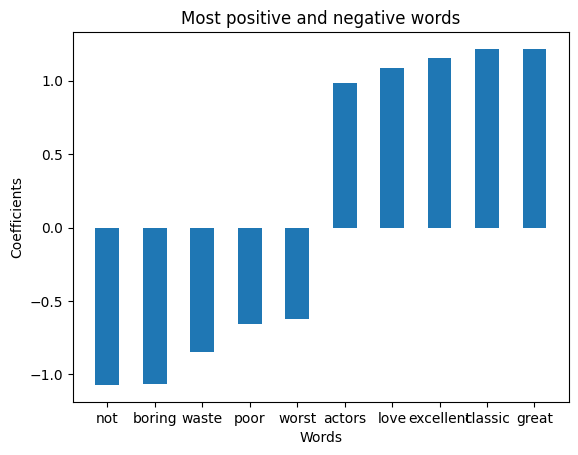

In [8]:
clf = LinearSVC(penalty = "l2", loss = "hinge", dual = True, C = 0.1, random_state = 445)
clf.fit(X_train, y_train)
coefficients = np.array(clf.coef_[0])
most_postitive_indicies = np.argpartition(coefficients, -5)[-5: ]
most_negative_indicies = np.argpartition(coefficients, 5)[:5]
values = {}
for i in most_postitive_indicies:
    values.update({list(dictionary_binary.keys())[i]:coefficients[i]})
for j in most_negative_indicies:
    values.update({list(dictionary_binary.keys())[j]:coefficients[j]})
values = dict(sorted(values.items(), key = lambda item: item[1]))

plt.bar(values.keys(), values.values(), width = 0.5)
plt.xlabel("Words")
plt.ylabel("Coefficients")
plt.title("Most positive and negative words")
plt.show

Part F:

Example: Terrible actors that I love to hate. A great piece of trash.

##### 3.2 Linear-Kernel SVM with L1 Penalty and Squared Hinge Loss

Part A:

In [9]:
C_range = [0.001, 0.01, 0.1, 1]
C = select_param_linear(X_train, y_train, k, 'auroc', C_range, 'squared_hinge', 'l1', False)
print("Best C:", C)
clf = LinearSVC(penalty = 'l1', loss = 'squared_hinge', dual = False, C = C, random_state = 445)
print("CV score:", cv_performance(clf, X_train, y_train, k, 'auroc'))
clf.fit(X_train, y_train)
y_pred = clf.decision_function(X_test)
print("Test Performance:", project1.performance(y_test, y_pred, 'auroc'))

Best C: 0.1
CV score: 0.9568577694595929
Test Performance: 0.9575131261896958


Part B:

In [10]:
plot_weight(X_train, y_train, 'l1', C_range, 'squared_hinge', False)

![title](Norm-l1_penalty.png)

Part C:

The range of L0-norm values for the L1 penalty graph is 0 through above 600. The L0-norm values start off low and then seem to increase at a faster rate as C increases. Comparatively, the range of L0-norm values for the L2 penalty graph is below 4000 to above 6000. The L0-norm values start off higher and then seem to decrease at a faster rate as C increases. In the case of L1, the gradient remains constant, which means that it's more likely for the model parameters to go to zero. This causes the range to include lower values than L2. However, with L2, the gradient decreases as our model parameters approach zero. This makes it less likely that the model parameters will go to zero. This causes the range of values to include much higher values than L1.

Part D:

Squared hinge loss penalizes misclassifications more than hinge loss. This means that it will likely result in an optimal solution with a larger margin than with hinge loss. 

##### 3.3 Hyperparameter Selection for a Quadratic-Kernel SVM

Part A: 

In [11]:
print("Grid Search")
C_range = [0.01, 0.1, 1, 10, 100, 1000]
r_range = [0.01, 0.1, 1, 10, 100, 1000]
param_range = []
for c in C_range:
    for r in r_range:
        param_range.append([c,r])
param_range = np.array(param_range)
maxC, maxr = select_param_quadratic(X_train, y_train, k, 'auroc', param_range)
print("Best C:", maxC, "Best coeff (r):", maxr)
clf = SVC(kernel = 'poly', degree = 2, C = maxC, coef0 = maxr, gamma = 'auto', random_state = 445)
clf.fit(X_train, y_train)
y_pred = clf.decision_function(X_test)
print("Test Performance:", project1.performance(y_test, y_pred, 'auroc'))

Grid Search
CV performance for C = 0.01 and r = 0.01 : 0.8881391911412951
CV performance for C = 0.01 and r = 0.1 : 0.8844850649862248
CV performance for C = 0.01 and r = 1.0 : 0.8842019475374385
CV performance for C = 0.01 and r = 10.0 : 0.8840167107820991
CV performance for C = 0.01 and r = 100.0 : 0.8840158116794035
CV performance for C = 0.01 and r = 1000.0 : 0.922892904232927
CV performance for C = 0.1 and r = 0.01 : 0.8881391911412951
CV performance for C = 0.1 and r = 0.1 : 0.8842692803393024
CV performance for C = 0.1 and r = 1.0 : 0.8840311180252918
CV performance for C = 0.1 and r = 10.0 : 0.8840167107820989
CV performance for C = 0.1 and r = 100.0 : 0.9226354152609749
CV performance for C = 0.1 and r = 1000.0 : 0.9546862987495237
CV performance for C = 1.0 and r = 0.01 : 0.8878721576407285
CV performance for C = 1.0 and r = 0.1 : 0.8843457040684207
CV performance for C = 1.0 and r = 1.0 : 0.884031118025292
CV performance for C = 1.0 and r = 10.0 : 0.9226173846069191
CV perfo

In [8]:
print("Random Search")
param_range = []
for i in range(25):
    C = 10**np.random.uniform(-2, 3)
    r = 10**np.random.uniform(-2, 3)
    param_range.append([C, r])
param_range = np.array(param_range)
maxC, maxr = select_param_quadratic(X_train, y_train, k, 'auroc', param_range)
print("Best C:", maxC, "Best coeff (r):", maxr)
clf = SVC(kernel = 'poly', degree = 2, C = maxC, coef0 = maxr, gamma = 'auto', random_state = 445)
clf.fit(X_train, y_train)
y_pred = clf.decision_function(X_test)
print("Test Performance:", project1.performance(y_test, y_pred, 'auroc'))

Random Search
CV performance for C = 23.9398854114593 and r = 149.69451812999273 : 0.9514708402095788
CV performance for C = 0.05504453805790518 and r = 17.001151716251737 : 0.8840149125767078
CV performance for C = 206.63119076786305 and r = 0.3679381648744585 : 0.9520035329065916
CV performance for C = 14.845102510538116 and r = 0.41858168673926444 : 0.9110993822759481
CV performance for C = 0.028397248630973832 and r = 30.22298914030225 : 0.8840167107820991
CV performance for C = 18.628507156514676 and r = 183.43260446407405 : 0.9505890013658259
CV performance for C = 0.05406613524303406 and r = 0.47896774105977574 : 0.8840545486955371
CV performance for C = 3.454560893960177 and r = 0.4283160598094511 : 0.8840698604414416
CV performance for C = 0.639174245442825 and r = 0.11365562394843744 : 0.884299714830545
CV performance for C = 1.6483895414669474 and r = 0.4077449831075029 : 0.8840734622522397
CV performance for C = 0.3679164959308665 and r = 58.18691290184949 : 0.9355631998184

| Tuning Scheme | C | r | AUROC |
| --- | --- | --- | --- |
| Grid Search | 100 | 10 | 0.9561782228893145 |
| Random Search | 20.761425609708787 | 42.071646793439115 | 0.9569056984628125 |

Part B:

For grid search, the scores seem to follow a general trend of increasing until the best r is found and then decreasing. It repeats this process with every new C value. There are a few instance where the score jumps up or ddown, but this is less common. For random search, the scores don't follow a distinct pattern and tend to be all over the place. This makes sense since we're randomly generating our C and r values. 


Advantage of grid search: Grid search is deterministic, which means that it will always give you the same output when given a fixed input. This makes the results reproducible without any variability. This is not possible with a random search, unless you generate the same set of random values every time. The deterministic approach also makes sure that the entire search space has been covered. 

Advantage of random search: Random search allows for more efficient exploration of the search space than grid search since it's randomly sampling combinations of C and r from the search space. Sine random search is not exhaustive like grid search, it takes less time/computing power and has the ability to yeild similar results. 

##### 3.4 Learning Non-linear Classifiers with a Linear-Kernel SVM

Part A: 

$K(x, x^{\prime}) =  (x * x^{\prime} + r)^{2}$

$\phi(\bar{x}) = [r,\:x_{1}\sqrt{2r},\:x_{2}\sqrt{2r},\:...,\:x_{n}\sqrt{2r},\:x_{1}x_{2}\sqrt{2},\:x_{1}x_{3}\sqrt{2},\:...,\:x_{1}x_{n}\sqrt{2},\:x_{2}x_{3}\sqrt{2},\:x_{2}x_{4}\sqrt{2},\:...,\:x_{2}x_{n}\sqrt{2},\:...,\:x_{n-1}x_{n}\sqrt{2},\:x^{2}_{1},\:x^{2}_{2},\:...,\:x^{2}_{n}]$

Part B:

Pros: Explicit feature mapping is interpretable since we can observe the features directly. Also, we have control over the feature space which is useful since we can make specific changes to the features if we need to. 

Cons: Explicit feature mapping is computationally expensive and could lead to overfitting in higher dimensions since the data becomes sparser.

#### Section 4: Asymmetric Cost Functions and Class Imbalance
##### 4.1 Arbitrary class weights

Part A:

If W_n is much greater than W_p, that means that the misclassification of a negative data point will lead to a much higher penalty than the misclassification of a positive data point. Since we're trying to minimize $\xi$, a larger W_n will lead to a larger $\xi$, which means the model is less likely to be the optimal model. So, this will led to models that avoid misclassifying negative points. More simply, correctly classifying negative points is considered more important than correctly classifying positive points. 

Part B:

W_n = 0.25 and W_p = 1 means that there is more penalty for misclassifying positive points than negative points. The objective function will put more emphasis on correctly classifying positive points than negative points. W_n = 1 and W_p = 4 still means that there is more penalty for misclassifying positive points than negative points. However, the model will be more focused on correctly classifying negative points than if W_n = 0.25. The objective function will still put more emphasis on correctly classifying positive points.  

Part C:

In [9]:
clf = LinearSVC(penalty = 'l2', loss = 'hinge', dual = True, C = 0.01, class_weight = {-1: 1, 1: 10}, random_state = 445)
clf.fit(X_train, y_train)
y_pred_auroc = clf.decision_function(X_test)
y_pred = clf.predict(X_test)
for metric in metrics_list:
    if metric == 'auroc':
        score = project1.performance(y_test, y_pred_auroc, metric)
    else:
        score = project1.performance(y_test, y_pred, metric)
    print(score)

0.7176258992805755
0.7773049645390071
0.9477741547768979
0.6416861826697893
0.9856115107913669
0.44964028776978415


| Performance Measures | Performance |
| --- | --- |
| Accuracy | 0.7176258992805755 |
| F1-Score | 0.7773049645390071 |
| AUROC | 0.9477741547768979 |
| Precision | 0.6416861826697893 |
| Sensitivity | 0.9856115107913669 |
| Specificity | 0.44964028776978415 |

Part D:

Accuracy: The performance metric decreased.

F1-Score: The performance metric decreased. 

AUROC: The performance metric decreased slightly. 

Precision: The performance metric decreased greatly. 

Sensitivity: The performance metric increased.

Specificity: The performance metric decreased greatly.

Since the positive weight is much greater than the negative weight, its expected that most of the positive points are correctly classified. Naturally this would decrease most performance metrics since it's likely that there is a larger amount of misclassified negative points. Precision and Specificity were greatly affected, probably because of the larger number of false positives. Sensitivity probably increased because of the larger number of true positives and lower number of false negatives. 

##### 4.2 Imbalanced data

Part A:

In [10]:
IMB_features, IMB_labels, IMB_test_features, IMB_test_labels = get_imbalanced_data(dictionary_binary, filename = "data/dataset.csv")
clf = LinearSVC(penalty = 'l2', loss = 'hinge', dual = True, C = 0.01, class_weight = {-1: 1, 1: 1}, random_state = 445)
clf.fit(IMB_features, IMB_labels)
y_pred_auroc = clf.decision_function(IMB_test_features)
y_pred = clf.predict(IMB_test_features)
for metric in metrics_list:
    if metric == 'auroc':
        score = project1.performance(IMB_test_labels, y_pred_auroc, metric)
    else:
        score = project1.performance(IMB_test_labels, y_pred, metric)
    print(score)

0.8427612655800575
0.9100877192982456
0.9427816598395924
0.8383838383838383
0.9952038369304557
0.23444976076555024


| Class Weights | Performance Measures | Performance |
| --- | --- | --- |
| W_n = 1, W_p = 1 | Accuracy | 0.8427612655800575 |
| W_n = 1, W_p = 1 | F1-Score | 0.9100877192982456 |
| W_n = 1, W_p = 1 | AUROC | 0.9427816598395924 |
| W_n = 1, W_p = 1 | Precision | 0.8383838383838383 |
| W_n = 1, W_p = 1 | Sensitivity | 0.9952038369304557 |
| W_n = 1, W_p = 1 | Specificity | 0.23444976076555024 |

Part B:

Sensitivity: This performance metric increased the most. This is probably because the number of true postitives is high and the number of false negatives is low. This means the model is very successful at identifying the positive points.

Specificity: This performance metric decreased the most. This probably because there are a very low number of true negatives and a high number of false positives. This means the model is very bad at identifying negative points. 

Part C:

The F1-score matches my intuition since F1-score takes the harmonic average of sensitivity and precision. Because both sensitivity and precision have high performance scores, it makes sense that f1-score would also have a high performance score that it between the other two scores. 

##### 4.3 Choosing appropriate class weights

Part A:

Since the dataset has roughtly four times the number of positive points as opposed to negative points, we have a rough idea of the class weights we should use. I want to use inversely proportional weights to give more importance to the negative points. I'll be doing a grid search, using 1-5 as my range for W_p and 6-10 as my range for W_n. I'll be using auroc as my performance metric since it seems to generally do well with imbalanced data, as seen in previous parts of this project. 

In [12]:
W_n_range = [6, 7, 8, 9, 10]
W_p_range = [1, 2, 3, 4, 5]
bestPerformance = 0
bestW_n = 0
bestW_p = 0
for W_n in W_n_range: 
    for W_p in W_p_range:
        clf = LinearSVC(penalty = 'l2', loss = 'hinge', dual = True, C = 0.01, class_weight = {-1: W_n, 1: W_p}, random_state = 445)
        performance = cv_performance(clf, IMB_features, IMB_labels, k, 'auroc')
        if performance > bestPerformance:
            bestPerformance = performance
            bestW_n = W_n
            bestW_p = W_p
print("class_weight={-1:", bestW_n, ", 1:", bestW_p, "}")
print("Performance score:", bestPerformance)

class_weight={-1: 9 , 1: 5 }
Performance score: 0.9538274389078806


Part B:

In [13]:
clf = LinearSVC(penalty = 'l2', loss = 'hinge', dual = True, C = 0.01, class_weight = {-1: bestW_n, 1: bestW_p}, random_state = 445)
clf.fit(IMB_features, IMB_labels)
y_pred_auroc = clf.decision_function(IMB_test_features)
y_pred = clf.predict(IMB_test_features)
for metric in metrics_list:
    if metric == 'auroc':
        score = project1.performance(IMB_test_labels, y_pred_auroc, metric)
    else:
        score = project1.performance(IMB_test_labels, y_pred, metric)
    print(score)

0.9213806327900288
0.9514792899408284
0.9567456082980506
0.9392523364485982
0.9640287769784173
0.7511961722488039


| Class Weights | Performance Measures | Performance |
| --- | --- | --- |
| W_n = 9, W_p = 5 | Accuracy | 0.9213806327900288 |
| W_n = 9, W_p = 5 | F1-Score | 0.9514792899408284 |
| W_n = 9, W_p = 5 | AUROC | 0.9567456082980506 |
| W_n = 9, W_p = 5 | Precision | 0.9392523364485982 |
| W_n = 9, W_p = 5 | Sensitivity | 0.9640287769784173 |
| W_n = 9, W_p = 5 | Specificity | 0.7511961722488039 |

##### 4.4 The ROC curve

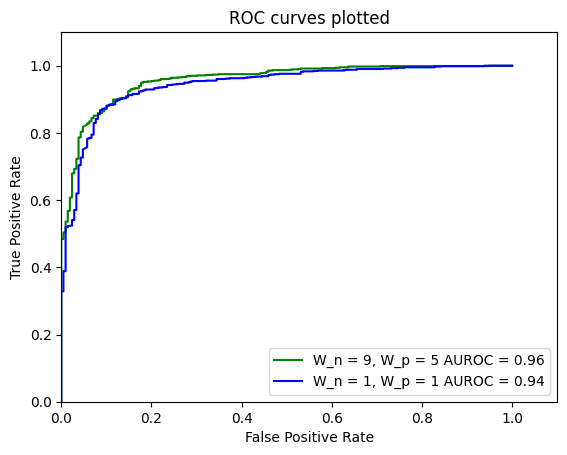

In [14]:
clf_weighted = LinearSVC(penalty = 'l2', loss = 'hinge', dual = True, C = 0.01, class_weight = {-1: bestW_n, 1: bestW_p}, random_state = 445)
clf_balanced = LinearSVC(penalty = 'l2', loss = 'hinge', dual = True, C = 0.01, class_weight = {-1: 1, 1: 1}, random_state = 445)
clf_weighted.fit(IMB_features, IMB_labels)
clf_balanced.fit(IMB_features, IMB_labels)
y_pred_weighted = clf_weighted.decision_function(IMB_test_features)
y_pred_balanced = clf_balanced.decision_function(IMB_test_features)
fpr_w, tpr_w, _ = metrics.roc_curve(IMB_test_labels, y_pred_weighted)
fpr_b, tpr_b, _ = metrics.roc_curve(IMB_test_labels, y_pred_balanced)
performance_weighted = project1.performance(IMB_test_labels, y_pred_weighted, 'auroc')
performance_balanced = project1.performance(IMB_test_labels, y_pred_balanced, 'auroc')
plt.plot(fpr_w, tpr_w, 'g', label='W_n = 9, W_p = 5 AUROC = %0.2f' % performance_weighted)
plt.plot(fpr_b, tpr_b, 'b', label='W_n = 1, W_p = 1 AUROC = %0.2f' % performance_balanced)
plt.legend(loc = "lower right")
plt.xlim([0, 1.1])
plt.ylim([0, 1.1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves plotted')
plt.show()

#### Section 5 Identifying Bias

##### 5.1 Dataset Exploration

Part A:

In [15]:
num_actors, num_actresses = count_actors_and_actresses(filename = 'data/dataset.csv')
print("Number of times 'actor or 'actors' appears:", num_actors)
print("Number of times 'actress' or 'actresses' appears:", num_actresses)

Number of times 'actor or 'actors' appears: 1933
Number of times 'actress' or 'actresses' appears: 221


The words 'actor' and 'actors' seems to appear much more that the words 'actress' and 'actresses'. This is probably because 'actor' and 'actors' is more of a general term that can include both males an females while 'actress' and 'actresses' is mostly used exclusively for females.

Part B:

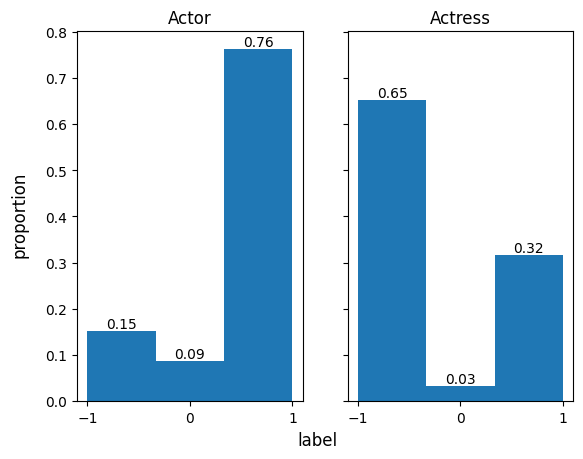

In [16]:
plot_actors_and_actresses(filename = 'data/dataset.csv', x_label = 'label')

It seems like a large proportion reviews that contain the words 'actress' or 'actresses' are negative while a large proportion of reivews that contain the words 'actor' or 'actors' are positive. We should definitely consider the possibility that there is a large implicit bias against female centric movies or movies that contain many female actors in these reviews. 

Part C:

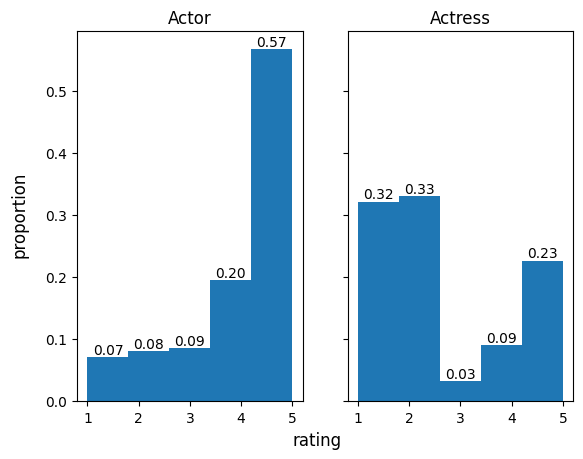

In [17]:
plot_actors_and_actresses(filename = 'data/dataset.csv', x_label = 'rating')

If the true data distribution shows that the columns 1 and 5 for the actors plot should be swapped, then the bias observed in the previous plot would not persist. This is because both actors and actresses would contain a similar proportion of negative reviews. This does not support the assertion that there are more negative reviews for female centric movies/movies that contain female actors.

Part D:

In [18]:
X_train, y_train, X_test, y_test, dictionary_binary = get_split_binary_data(filename = 'data/dataset.csv')
clf = LinearSVC(penalty = 'l2', loss = 'hinge', dual = True, C = 0.1, random_state = 445)
clf.fit(X_train, y_train)
coefficients = np.array(clf.coef_[0])
print("Coefficient for 'actor':", coefficients[dictionary_binary['actor']])
print("Coefficient for 'actress':", coefficients[dictionary_binary['actress']])

Coefficient for 'actor': 0.8600551555622434
Coefficient for 'actress': -0.08595275109425773


We can see that the coefficient for 'actor' is positive while the coefficient for 'actress' is negative. These coefficents indicate that the model has learned form a bias from the dataset, since it associates two inherently neutral words with positive or negative connotation. This shows why model interpretability is so important. If our model was less interpretable, it would be less likely that we'd be able to spot this bias in our model and be able to correct it.

##### 5.2 Word Embeddings

Part A:

In [19]:
word_vec = train_word2vec(filename = 'data/dataset.csv')
print("Word embedding for 'actor':", word_vec.wv['actor'])
print("Dimensionality:", np.shape(word_vec.wv['actor']))

Word embedding for 'actor': [ 0.36327884  0.38181713 -0.20518531  0.13006854 -0.07237589 -0.6196435
  0.59835285  0.4691895  -0.27421442 -0.45487142  0.14542596 -0.7742505
  0.29315308  0.00906786  0.03568592 -0.276758    1.118521   -0.2613945
 -0.23835392 -0.37399897  0.4060288   0.557281    0.28096205 -0.06152146
 -0.16506627 -0.08475478 -0.94372356  0.36999425 -0.25212488  0.03817452
 -0.008118    0.11717194  0.01024978 -0.2239969  -0.44825053  0.00546879
 -0.05945418 -0.05354258 -0.24315809 -0.02456791  0.44446927 -0.31160858
  0.07441755  0.27232432  0.5877642  -0.42877096 -0.15183628 -0.11123671
  0.6664703   0.60949683 -0.20928076 -0.56690115  0.13344821 -0.41864175
  0.2154863   0.31742975  0.5465455   0.00285962 -0.19922979  0.27098113
 -0.3858346  -0.57065696  0.31181523  0.18224728 -0.280035    0.6822779
  0.02185942  0.37339458 -0.5253754   0.7040062   0.0389593   0.0410245
  0.9755299  -0.19808131  0.44829524  0.32826063  0.4006641  -0.19505996
 -0.43223137 -0.4106199  -0.

Part B:

In [20]:
similar_words = word_vec.wv.most_similar('actor', topn = 5)
for word in similar_words:
    print(word)

('industry', 0.9419273138046265)
('bullock', 0.9234532117843628)
('action', 0.9221456050872803)
('quality', 0.9172305464744568)
('cast', 0.9118165969848633)


Since the dataset we're working with contains movie reviews, this means that the five other words most similar to 'actor' will likely be related to film vocabulary. As we can see, the word 'industry' likely has something to do with the acting/film industry, the word 'bullock' is likely a direct reference to Sandra Bullock, etc. If the context was geometry rather than movies, the similar words would probably be completely difference, since 'industry', 'bullock', 'action', 'quality', and 'cast' have little to do with geometry.

##### 5.3 Word Embedding Association Test

Part A:

In [21]:
A = ['her', 'woman', 'women']
B = ['him', 'man', 'men']
w = 'smart'
s = compute_association('data/dataset.csv', w, A, B)
print("Association:", s)

Association: -0.06205581472636712


Part B:

Based on the WEAT association score, we can conclude that the word 'smart' is more closely associated with the list of words B over the list of words A. This means that, on average, the words 'him', 'man', and 'men' are closer to 'smart' than the words 'her', 'woman', and 'women'. This is because the score is negative, which means that the average cosine_similarity for B is larger than A. This relates to our identified bias since 'smart' is not an inherently gendered word and the fact that it's more related to man idenfiers than female ones means that our model has developed a bias. 

#### Section 6 Challenge

##### Preprocessing/Feature engineering:

I decided to do the following steps to preprocess the data:
1. call extract_word on data to remove punctuation
2. remove all stop words from the data
3. remove all one letter words from data
4. remove all numbers from data
I decided on these steps since it removes any common words in english and punctuation that wouldn't contribute much to the model if they were included. I also don't believe that the numbers are very important to the model so I removed those as well. It makes sure that most of the features present are relevant to the problem in some way. 

##### Hyperparameter selection:

I chose to optimize for accuracy since it's straightforward and interpretable. We're also being graded for accuracy, so it seems like the smartest thing to optimize for. I used select_param_linear() to find an appropriate C-value for my model, since I decided to go with a linear kernel opposed to a quadratic kernel. More on that in the next section. 

##### Algorithm selection:

I tried using both the quadratic kernal and the linear kernel to see which would would work better. Both ended up performing about the same but I ended up going with linear kernel since it was faster. Linear kernel also works well for high dimensional problems since there isn't as much worry about overfitting the data. I also decided to use L2-penalty since I wanted most of the features to contribute to the model rather than minimize the number of features. I also used hinge loss because I wanted to maximize the margin between classes. I decided not to include any class weights since the dataset we've been given is fairly balanced. 

##### Multi-class method:

Since LinearSVC uses a one vs. rest strategy, I decided to use that method. It's computationally more efficient than one vs. one so I'm sure my old computer will appreciate it. 



In [2]:
multiclass_features, multiclass_labels, multiclass_dictionary = helper.get_multiclass_training_data()
heldout_features = helper.get_heldout_reviews(multiclass_dictionary)
C_range = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
bestC = select_param(multiclass_features, multiclass_labels, k = 5, metric = 'accuracy', C_range = C_range, loss = 'hinge', penalty = 'l2', dual = True)
print("C value:", bestC)
clf = LinearSVC('l2', 'hinge', dual = True, C = bestC, random_state = 445)
print("CV score:", cv_performance_multi(clf, multiclass_features, multiclass_labels, k = 5, metric = 'accuracy'))
clf.fit(multiclass_features, multiclass_labels)
y_pred = clf.predict(heldout_features)
generate_challenge_labels(y_pred, 'yojozho')

C value: 0.1
CV score: 0.6911111111111111
